## SETUP – Imports & sökvägar
Nödvändiga bibliotek importeras och projektets mappstruktur definieras med `pathlib`. Mapparna `data/`, `models/` och `outputs/` skapas automatiskt om de inte redan finns.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR   = Path().resolve()
DATA_DIR   = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Projektmappar klara:")
for d in [DATA_DIR, MODELS_DIR, OUTPUT_DIR]:
    print(f"  {d}")

Projektmappar klara:
  C:\Users\petarv01\Documents\PYTHON\breast-cancer\data
  C:\Users\petarv01\Documents\PYTHON\breast-cancer\models
  C:\Users\petarv01\Documents\PYTHON\breast-cancer\outputs


## CELL 1 – Exportera dataset till CSV
Breast Cancer Wisconsin-datasetet laddas från scikit-learn och sparas som en lokal CSV-fil. Detta simulerar ett verkligt arbetsflöde där data läses in från disk.

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

df_export = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_export["target"] = cancer.target

csv_path = DATA_DIR / "breast_cancer.csv"
df_export.to_csv(csv_path, index=False)

print(f"Dataset sparat till: {csv_path}")
print(f"Shape: {df_export.shape}")

Dataset sparat till: C:\Users\petarv01\Documents\PYTHON\breast-cancer\data\breast_cancer.csv
Shape: (569, 31)


## CELL 2 – Läs in dataset från CSV
Datasetet läses in från den lokala CSV-filen med `pd.read_csv()`. Från detta steg arbetar projektet enbart mot lokal data, precis som med ett eget dataset.

In [3]:
df = pd.read_csv(DATA_DIR / "breast_cancer.csv")

print("Dataset inläst från CSV.")
print(f"Shape: {df.shape}")
df.head()

Dataset inläst från CSV.
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## CELL 3 – EDA: Datastruktur
En första översikt av datasetet visar kolumntyper, antal rader och om det finns saknade värden. Datasetet innehåller 569 prover, 30 numeriska features och inga null-värden.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## CELL 4 – EDA: Statistik och klassfördelning
Deskriptiv statistik ger en bild av featurernas spridning och skala. Klassfördelningen visar 357 benigna (1) och 212 maligna (0) prover — en viss obalans som är värd att notera.

In [5]:
display(df.describe())
print("\nTarget-fördelning:")
print(df["target"].value_counts())
print(f"  0 = malignant, 1 = benign")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Target-fördelning:
target
1    357
0    212
Name: count, dtype: int64
  0 = malignant, 1 = benign


## CELL 5 – Datastädning: Identifiera irrelevanta kolumner
Pearson-korrelation beräknas mellan varje feature och target. Features med absolut korrelation under 0.3 bidrar minimalt till klassificeringen och markeras för borttagning.

Korrelation mot target (stigande ordning):
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
fractal dimension error    0.077972
concavity error            0.253730
compactness error          0.292999
worst fractal dimension    0.323872
mean symmetry              0.330499
mean smoothness            0.358560
concave points error       0.408042
mean texture               0.415185
worst symmetry             0.416294
worst smoothness           0.421465
worst texture              0.456903
area error                 0.548236
perimeter error            0.556141
radius error               0.567134
worst compactness          0.590998
mean compactness           0.596534
worst concavity            0.659610
mean concavity             0.696360
mean area                  0.708984
mean radius                0.730029
worst area                 0.733825
mean perimeter             0.742636
worst radius         

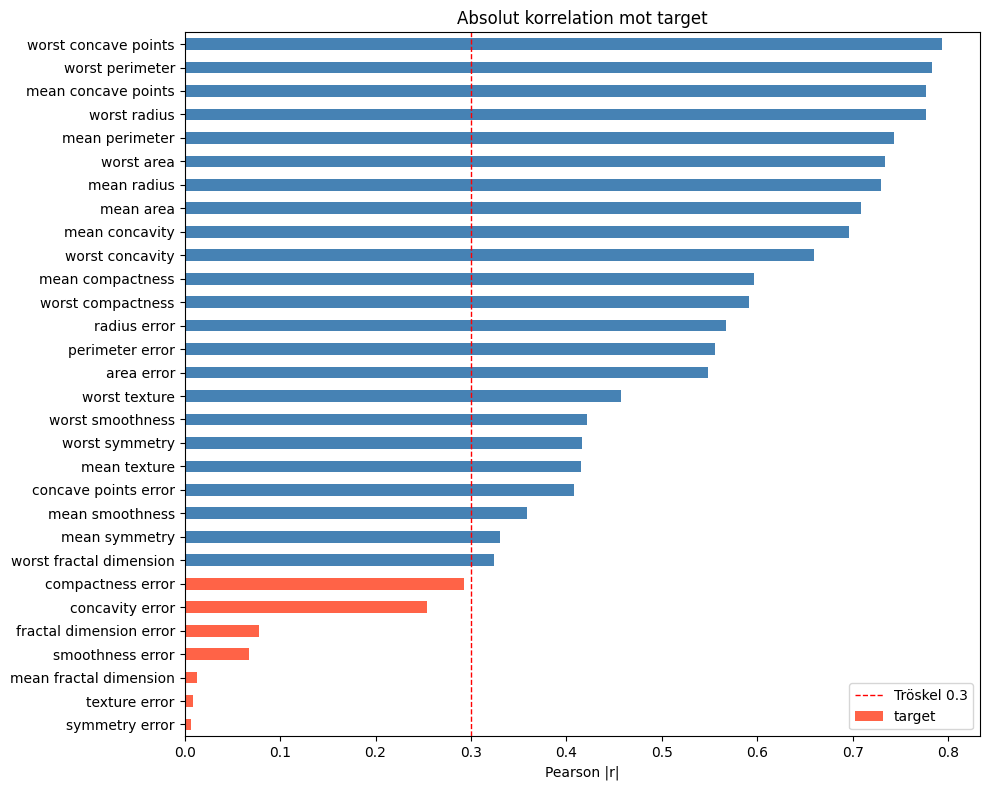

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

correlations = df.corr()["target"].drop("target").abs().sort_values()

print("Korrelation mot target (stigande ordning):")
print(correlations.to_string())

plt.figure(figsize=(10, 8))
correlations.plot(kind="barh", color=[
    "tomato" if v < 0.3 else "steelblue" for v in correlations
])
plt.axvline(x=0.3, color="red", linestyle="--", linewidth=1, label="Tröskel 0.3")
plt.title("Absolut korrelation mot target")
plt.xlabel("Pearson |r|")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_with_target.png", dpi=150, bbox_inches="tight")
print("Sparad: outputs/correlation_with_target.png")
plt.show()

## CELL 6 – Datastädning: Ta bort svagt korrelerade kolumner
Sju kolumner med korrelation under tröskeln 0.3 tas bort. Datasetet minskar från 30 till 23 features, vilket reducerar brus utan att förlora viktig information.

In [7]:
THRESHOLD = 0.3
low_corr_cols = correlations[correlations < THRESHOLD].index.tolist()

print(f"Kolumner med |korrelation| < {THRESHOLD} (tas bort):")
for col in low_corr_cols:
    print(f"  {col}: {correlations[col]:.3f}")

df_clean = df.drop(columns=low_corr_cols)

print(f"\nShape före städning: {df.shape}")
print(f"Shape efter städning: {df_clean.shape}")
print(f"Antal borttagna kolumner: {len(low_corr_cols)}")

Kolumner med |korrelation| < 0.3 (tas bort):
  symmetry error: 0.007
  texture error: 0.008
  mean fractal dimension: 0.013
  smoothness error: 0.067
  fractal dimension error: 0.078
  concavity error: 0.254
  compactness error: 0.293

Shape före städning: (569, 31)
Shape efter städning: (569, 24)
Antal borttagna kolumner: 7


## CELL 7 – Train/Test-split och normalisering
Data delas upp i 80% träning och 20% test med `random_state=42` för reproducerbarhet. `StandardScaler` normaliserar featurerna — ett nödvändigt steg för avståndbaserade modeller som SVM.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=["target"]).values
y = df_clean["target"].values
feature_names = df_clean.drop(columns=["target"]).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train/test split + normalisering klar.")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Train/test split + normalisering klar.
X_train: (455, 23), X_test: (114, 23)


## MODELLTRÄNING
Fyra klassificeringsmodeller tränas på det förbehandlade träningssetet. Varje modell representerar en olika teknik och ger ett bredare underlag för jämförelse.

### SVM
Support Vector Machine med RBF-kärna söker det optimala hyperplanet som separerar klasserna. Modellen är känslig för skalning, vilket gör normaliseringen ovan särskilt viktig.

In [9]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")
print(f"  Support vectors: {svm_model.support_vectors_.shape[0]}")

SVM model trained successfully.
  Support vectors: 94


### Random Forest
En ensemble av 200 beslutsträd tränas där varje träd röstar om klassificeringen. Modellen är robust mot outliers och ger feature importance som hjälper tolka vilka attribut som väger tyngst.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")
print(f"  Antal träd: {len(rf_model.estimators_)}")

print("\nTop 10 feature importances:")
importances = sorted(
    zip(feature_names, rf_model.feature_importances_),
    key=lambda x: x[1], reverse=True
)
for name, imp in importances[:10]:
    print(f"  {name}: {imp:.4f}")

Random Forest model trained successfully.
  Antal träd: 200

Top 10 feature importances:
  worst concave points: 0.1513
  worst radius: 0.1288
  mean concave points: 0.1065
  worst area: 0.0989
  worst perimeter: 0.0974
  mean perimeter: 0.0668
  mean concavity: 0.0587
  mean area: 0.0383
  mean radius: 0.0351
  worst concavity: 0.0312


### Logistisk Regression
En linjär modell som skattar sannolikheten för att ett prov är malignt. `max_iter=1000` säkerställer att modellen hinner konvergera med normaliserad data.

In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

print("\nTop 10 features by absolute coefficient:")
coef_df = pd.DataFrame({
    "Feature":     feature_names,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=np.abs, ascending=False)
print(coef_df.head(10).to_string(index=False))

Logistic Regression model trained successfully.

Top 10 features by absolute coefficient:
             Feature  Coefficient
worst concave points    -1.237815
        radius error    -1.219263
       worst texture    -1.216590
 mean concave points    -1.167650
      worst symmetry    -0.995357
        worst radius    -0.991433
    worst smoothness    -0.953510
    mean compactness     0.922724
          worst area    -0.891682
          area error    -0.830818


### Beslutsträd
Ett enkelt beslutsträd tränas som referensmodell. Modellen delar upp data i grenar baserat på feature-värden och är lätt att tolka och visualisera.

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree model trained successfully.")
print(f"  Träddjup: {dt_model.get_depth()}")
print(f"  Antal löv: {dt_model.get_n_leaves()}")

Decision Tree model trained successfully.
  Träddjup: 8
  Antal löv: 17


## SPARA MODELLER
Tränade modeller och scaler serialiseras med `joblib` och sparas i `models/`. Scaler sparas tillsammans med modellerna så att ny data kan normaliseras på exakt samma sätt vid återanvändning.

In [13]:
import joblib

joblib.dump(svm_model, MODELS_DIR / "svm_model_optimized.pkl")
joblib.dump(rf_model,  MODELS_DIR / "rf_model.pkl")
joblib.dump(lr_model,  MODELS_DIR / "lr_model.pkl")
joblib.dump(dt_model,  MODELS_DIR / "dt_model.pkl")
joblib.dump(scaler,    MODELS_DIR / "scaler.pkl")

print("Modeller sparade till models/:")
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Modeller sparade till models/:
  dt_model.pkl  (3.8 KB)
  lr_model.pkl  (1.0 KB)
  rf_model.pkl  (656.6 KB)
  scaler.pkl  (1.1 KB)
  svm_model.pkl  (20.4 KB)
  svm_model_optimized.pkl  (20.4 KB)


## HYPERPARAMETERTUNING – GridSearchCV (SVM)
GridSearchCV söker systematiskt igenom ett rutnät av hyperparametrar och hittar den kombination som ger bäst prestanda via korsvalidering. Här optimeras `C` (regulariseringsstyrka) och `gamma` för SVM med RBF-kärna.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
}

grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='recall_weighted',  # recall prioriteras för medicinskt problem
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Bästa parametrar:", grid_search.best_params_)
print("Bästa korsvaliderings-score (recall):", grid_search.best_score_.round(4))

# Uppdatera svm_model med optimerade parametrar
svm_model = grid_search.best_estimator_
print("\nSVM-modellen uppdaterad med optimerade hyperparametrar.")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Bästa parametrar: {'C': 10, 'gamma': 0.01}
Bästa korsvaliderings-score (recall): 0.9736

SVM-modellen uppdaterad med optimerade hyperparametrar.


## KORSVALIDERING – Alla modeller
Korsvalidering (k-fold, k=5) delar upp träningsdatan i 5 delar och tränar modellen 5 gånger. Detta ger en mer robust uppskattning av prestandan än ett enda train/test-split, och avslöjar om modellen är känslig för hur datan delas upp.

In [15]:
from sklearn.model_selection import cross_val_score
import numpy as np

models_cv = {
    "SVM (optimerad)":    svm_model,
    "Random Forest":      rf_model,
    "Logistic Regression": lr_model,
    "Decision Tree":      dt_model,
}

print("Korsvalidering (k=5, scoring=recall_weighted):\n")
cv_results = {}

for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall_weighted')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Scores:  {scores.round(4)}")
    print(f"  Medel:   {scores.mean():.4f}")
    print(f"  Std dev: {scores.std():.4f}\n")

Korsvalidering (k=5, scoring=recall_weighted):

SVM (optimerad):
  Scores:  [0.989  0.967  0.978  0.989  0.9451]
  Medel:   0.9736
  Std dev: 0.0164

Random Forest:
  Scores:  [0.978  0.9341 0.978  0.956  0.9451]
  Medel:   0.9582
  Std dev: 0.0176

Logistic Regression:
  Scores:  [0.989  0.967  0.989  0.978  0.9341]
  Medel:   0.9714
  Std dev: 0.0204

Decision Tree:
  Scores:  [0.9121 0.9341 0.9341 0.9451 0.9341]
  Medel:   0.9319
  Std dev: 0.0108



## KORSVALIDERING – Visualisering
Boxplot visar spridningen i korsvaliderings-scores per modell. En låg standardavvikelse indikerar att modellen är stabil och inte känslig för uppdelningen av datan.

Sparad: outputs/cross_validation.png


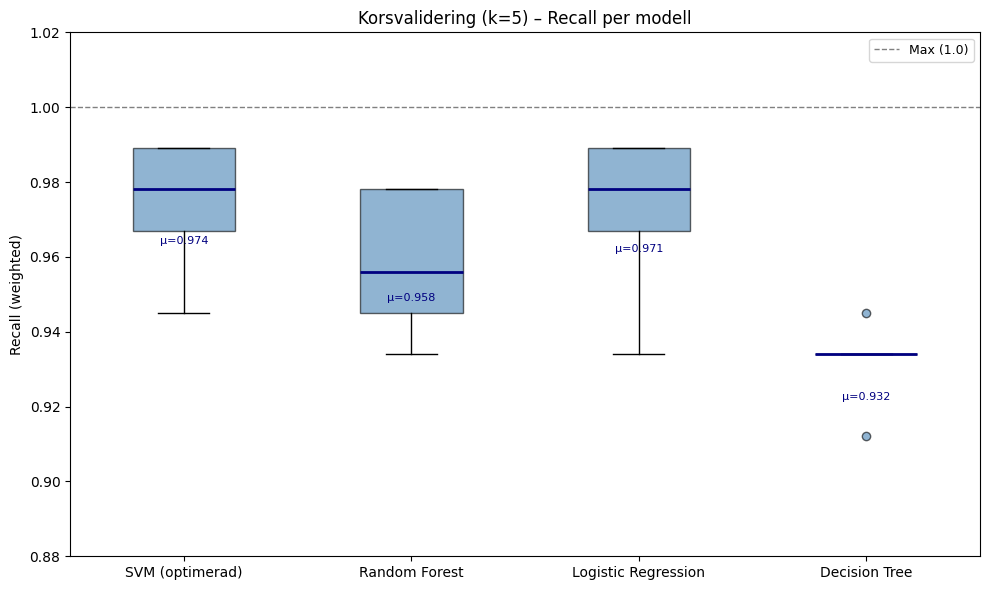

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(
    cv_results.values(),
    tick_labels=cv_results.keys(),
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="navy", linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='steelblue', markersize=6, alpha=0.6)
)

ax.set_title("Korsvalidering (k=5) – Recall per modell")
ax.set_ylabel("Recall (weighted)")
ax.set_ylim([0.88, 1.02])
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, label="Max (1.0)")

# Visa medelvärde per modell
for j, (name, scores) in enumerate(cv_results.items(), start=1):
    ax.text(j, scores.mean() - 0.008, f'μ={scores.mean():.3f}',
            ha='center', va='top', fontsize=8, color='navy')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_validation.png", dpi=150, bbox_inches="tight")
print("Sparad: outputs/cross_validation.png")
plt.show()

## UTVÄRDERING
En gemensam evalueringsfunktion beräknar accuracy, precision, recall och F1-score för valfri modell. I ett medicinskt sammanhang är recall särskilt viktigt — ett falskt negativt resultat innebär ett missat cancerfall.

In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

def evaluate_model(model, X_test, y_test, name=None):
    y_pred = model.predict(X_test)
    label = name or model.__class__.__name__
    print(f"Evaluating model: {label}\n")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:   ", recall_score(y_test, y_pred, average='weighted'))
    print("F1-score: ", f1_score(y_test, y_pred, average='weighted'))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=cancer.target_names))
    return {
        "Model":     label,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall":    recall_score(y_test, y_pred, average='weighted'),
        "F1-score":  f1_score(y_test, y_pred, average='weighted')
    }

### SVM – Utvärdering

In [18]:
_ = evaluate_model(svm_model, X_test, y_test)

Evaluating model: SVC

Accuracy:  0.9824561403508771
Precision: 0.9829367940398942
Recall:    0.9824561403508771
F1-score:  0.9823691172375383

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Random Forest – Utvärdering

In [19]:
_ = evaluate_model(rf_model, X_test, y_test)

Evaluating model: RandomForestClassifier

Accuracy:  0.9649122807017544
Precision: 0.9652053622194477
Recall:    0.9649122807017544
F1-score:  0.9647382344750765

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Logistisk Regression – Utvärdering

In [20]:
_ = evaluate_model(lr_model, X_test, y_test)

Evaluating model: LogisticRegression

Accuracy:  0.9736842105263158
Precision: 0.9737190197716513
Recall:    0.9736842105263158
F1-score:  0.973621425014614

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Beslutsträd – Utvärdering

In [21]:
_ = evaluate_model(dt_model, X_test, y_test)

Evaluating model: DecisionTreeClassifier

Accuracy:  0.9122807017543859
Precision: 0.9136028476989575
Recall:    0.9122807017543859
F1-score:  0.9126509455456824

Classification Report:
              precision    recall  f1-score   support

   malignant       0.87      0.91      0.89        43
      benign       0.94      0.92      0.93        71

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



## MODELLJÄMFÖRELSE
Alla fyra modeller utvärderas mot samma testdata och sammanställs i en tabell. Detta ger en direkt jämförelse av modellernas prestanda på det städade datasetet.

In [22]:
results = [
    evaluate_model(svm_model, X_test, y_test, "SVM"),
    evaluate_model(rf_model,  X_test, y_test, "Random Forest"),
    evaluate_model(lr_model,  X_test, y_test, "Logistic Regression"),
    evaluate_model(dt_model,  X_test, y_test, "Decision Tree"),
]

comparison_df = pd.DataFrame(results)
comparison_df

Evaluating model: SVM

Accuracy:  0.9824561403508771
Precision: 0.9829367940398942
Recall:    0.9824561403508771
F1-score:  0.9823691172375383

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Evaluating model: Random Forest

Accuracy:  0.9649122807017544
Precision: 0.9652053622194477
Recall:    0.9649122807017544
F1-score:  0.9647382344750765

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Ev

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.982456,0.982937,0.982456,0.982369
1,Random Forest,0.964912,0.965205,0.964912,0.964738
2,Logistic Regression,0.973684,0.973719,0.973684,0.973621
3,Decision Tree,0.912281,0.913603,0.912281,0.912651


## CONFUSION MATRIX HEATMAPS
Confusion matrices visualiserar fördelningen av korrekta och felaktiga prediktioner per klass. Axlarna visar klassnamnen `malignant` och `benign` för tydligare tolkning.

Sparad: outputs/confusion_matrices.png


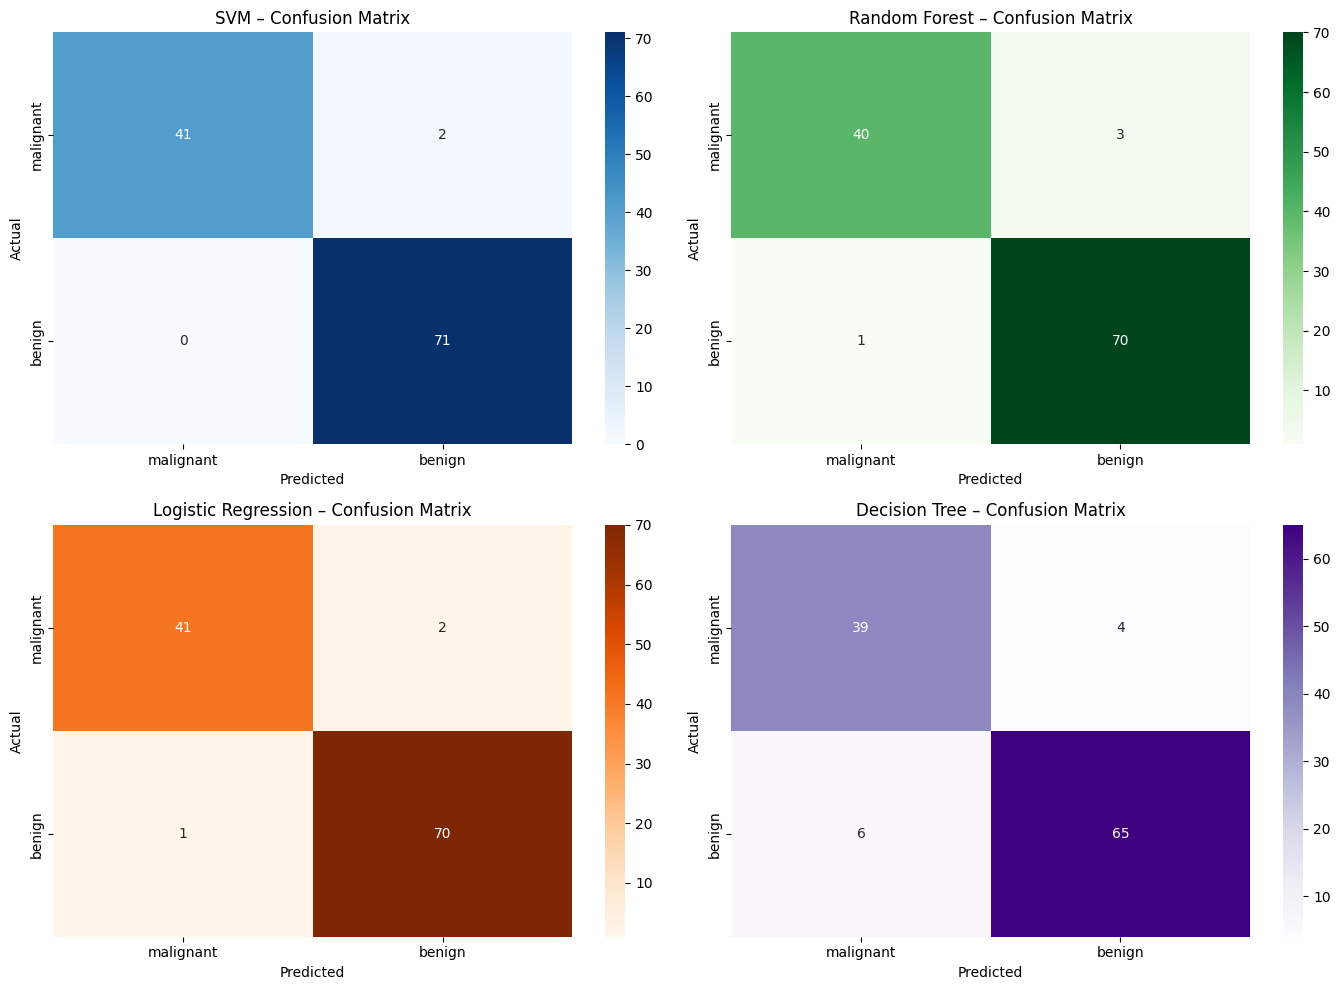

In [23]:
class_names = list(cancer.target_names)

svm_cm = confusion_matrix(y_test, svm_model.predict(X_test))
rf_cm  = confusion_matrix(y_test, rf_model.predict(X_test))
lr_cm  = confusion_matrix(y_test, lr_model.predict(X_test))
dt_cm  = confusion_matrix(y_test, dt_model.predict(X_test))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, cm, title, cmap in zip(
    axes.flatten(),
    [svm_cm, rf_cm, lr_cm, dt_cm],
    ["SVM", "Random Forest", "Logistic Regression", "Decision Tree"],
    ["Blues", "Greens", "Oranges", "Purples"]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"{title} – Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
print("Sparad: outputs/confusion_matrices.png")
plt.show()

## ROC-KURVA
ROC-kurvan visar avvägningen mellan true positive rate och false positive rate för olika tröskelvärden. AUC (arean under kurvan) sammanfattar modellens förmåga att skilja klasserna åt — ett värde nära 1.0 är bäst.

Sparad: outputs/roc_curve.png


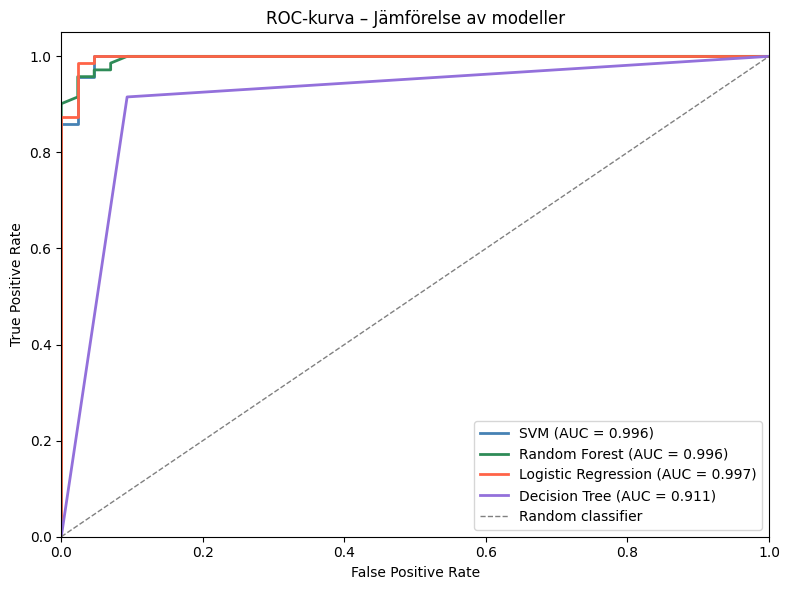

In [24]:
from sklearn.metrics import roc_curve, auc

models_roc = {
    "SVM":                 svm_model.decision_function(X_test),
    "Random Forest":       rf_model.predict_proba(X_test)[:, 1],
    "Logistic Regression": lr_model.predict_proba(X_test)[:, 1],
    "Decision Tree":       dt_model.predict_proba(X_test)[:, 1],
}
colors = {
    "SVM":                 "steelblue",
    "Random Forest":       "seagreen",
    "Logistic Regression": "tomato",
    "Decision Tree":       "mediumpurple",
}

plt.figure(figsize=(8, 6))
for name, scores in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[name], lw=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurva – Jämförelse av modeller")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
print("Sparad: outputs/roc_curve.png")
plt.show()

## SAMMANFATTNING – Sparade filer
Alla genererade filer listas med storlek. `models/` innehåller sparade modeller redo för återanvändning, `outputs/` innehåller de grafiska resultaten.

In [25]:
print("=== models/ ===")
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

print("\n=== outputs/ ===")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

=== models/ ===
  dt_model.pkl  (3.8 KB)
  lr_model.pkl  (1.0 KB)
  rf_model.pkl  (656.6 KB)
  scaler.pkl  (1.1 KB)
  svm_model.pkl  (20.4 KB)
  svm_model_optimized.pkl  (20.4 KB)

=== outputs/ ===
  confusion_matrices.png  (90.5 KB)
  correlation_with_target.png  (111.0 KB)
  cross_validation.png  (49.1 KB)
  roc_curve.png  (74.9 KB)
